# JLT invited — end-to-end BPAM-4, Asfand RX (64-128-32), initialized at the classical transceiver

Same chain as `bpam_complex.ipynb` except for **the initialization** and the TX pulse.

The autoencoder is initialized at the **classical BPAM transceiver** and then fine-tuned end-to-end
with no constraints -- the standard pre-training + fine-tuning scheme (in end-to-end learning the
transmitter is routinely initialized at a conventional constellation).

Why: left to a standard initialization the autoencoder always converges to a **unipolar** (intensity)
signalling -- two OOK streams half a symbol apart -- and never uses the bipolar BPAM format, even
where bipolar is available and better. Verified negative for a standard init, for the differential
precoder alone, for rescaled initial weights (gain 3/5/10) and for a low-SNR curriculum.

The TX pulse matters too: this notebook uses the **NRZ pulse cascaded with the 20 GHz rect**, not the
bare frequency rect used by `bpam_complex`. The bare rect has h(T/2) = 0 exactly, which nulls the
adjacent-pulse cross term that carries the differential sign, so a bipolar constellation is
undecodable with it. Cascade: h(T/2) = 0.45, and the 20 GHz band limit is preserved.

The differential precoder is required (`PRECODE = True`): in direct detection the absolute sign is
unobservable, only its changes are.

Outputs: `bpam_warmstart.txt` / `.pdf` / `.png` (the `bpam_complex` files are left untouched).


Workspace layout: this notebook writes to `results/bpam_warmstart/`. Published artifacts remain separately in `results/paper/`.


## 1. Setup and knobs

In [1]:
# Resolve paths independently of the notebook's working directory.
from pathlib import Path
import os
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "functions" / "config.py").is_file())
sys.path.insert(0, str(PROJECT_ROOT / "functions"))
os.chdir(PROJECT_ROOT)

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "functions")

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from scenarios import asfand_complex, checkpoint_name, OSNR_OFFSET_DB, TRAIN_EBN0_DB, TRAIN_STEPS
from train import train, evaluate

%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---------------- knobs ----------------
ADC_BITS   = [8, 6, 5]        # the family of the paper figure
PRECODE    = True             # REQUIRED by the warm-start (the absolute sign is unobservable in DD)
WARM_START = True             # initialize at the classical transceiver, then FREE end-to-end fine-tune
TX_PULSE   = "nrz"            # NRZ pulse out of the DAC ...
NRZ_RECT   = 1.0              # ... CASCADED with the ideal 20 GHz rect (cutoff in units of Rs).
                              # h(T/2): NRZ 0.61 -> cascade 0.45 -> freq-rect alone 0.00.
                              # The 20 GHz band limit is kept; only the pulse shape changes.
SEED       = 0
NUM_STEPS  = TRAIN_STEPS      # 100k
FORCE_RETRAIN = True

OSNR_GRID = list(range(11, 21))
EBN0_FOR_OSNR = [o - OSNR_OFFSET_DB for o in OSNR_GRID]

def num_symbols(ebn0_db):
    return 4_000_000 if ebn0_db <= 14.0 else 16_000_000

print(asfand_complex(adc_bits=6, precode=PRECODE, rx="asfand").summary())
print("warm-start:", WARM_START)

CHECKPOINT_DIR = os.path.join("results", "bpam_warmstart", "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


device: cuda
symbol rate          : 20 GBaud
bit rate             : 40 Gb/s  (bipolar PAM-4/DD (differential sign, 2 rx sps))
sim sample rate      : 40 GHz  (2 sps, Nyquist 20 GHz)
rx sample rate       : 40 GHz  (2 sps)
photodiode bandwidth : 25 GHz  (representable: False)
modulator            : mzm  (MZM 30 GHz, 1 segments)
pulse shape          : freq-rect 20 GHz (brickwall)
equalizer            : DPD (TX) + FFE (RX), trained jointly
wavelength band      : cband  (1550 nm, beta2 -21.7 ps^2/km, L 10.238 km, beta2*L -222.2 ps^2)
noise regime         : ase
optical filter       : wss, Bo 37 GHz
warm-start: True


## 2. Two stages: RX against the standard BPAM TX, then joint training

**Stage 1** — train the receiver against the **standard BPAM transmitter** (no predistorter,
`equalizer="ffe"`): the classical system *of this same chain*, so the receiver sees exactly the
statistics it will meet in stage 2. (Importing instead the receiver of `bpam_rxonly`, which runs on a
different chain, costs a factor 12 -- the mismatch is never recovered.)

**Stage 2** — joint TX + RX training. The predistorter starts pre-trained on the classical BPAM
constellation, the receiver is the one from stage 1, and from there the fine-tuning is
**unconstrained**: no imposed levels, no extra loss term. The network then moves ~83% RMS away from
the classical levels, uses its context memory and fills the T/2 slot the classical TX leaves empty.


In [2]:
from transmitter import Transmitter
from receiver import Receiver
from channel import OpticalChannel


def chain(adc_bits, equalizer="end-to-end"):
    """The chain, identical for both stages. equalizer='ffe' -> TX fixed at the classical BPAM levels."""
    cfg = asfand_complex(adc_bits=adc_bits, precode=PRECODE, rx="asfand")
    cfg.tx_filter = TX_PULSE                 # NRZ pulse, then the 20 GHz rect in cascade: keeps the
    cfg.nrz_rect_cutoff_ratio = NRZ_RECT     # T/2 cross term that carries the differential sign
    cfg.equalizer = equalizer                # (the bare freq-rect nulls it: h(T/2) = 0)
    cfg._compute_derived(); cfg.set_modulation_format("bpam-4")
    return cfg


def stage1_receiver(adc_bits, force_retrain=False):
    """STAGE 1 -- train the RX against the STANDARD BPAM transmitter (no predistorter).
    That is the classical system of this same chain; it seeds stage 2."""
    cfg = chain(adc_bits, equalizer="ffe")
    path = os.path.join(CHECKPOINT_DIR, f"warmstart_stage1_rx_adc{adc_bits}_seed{SEED}_{NUM_STEPS // 1000}k.pt")
    torch.manual_seed(SEED); np.random.seed(SEED)
    if os.path.exists(path) and not force_retrain:
        print(f"stage 1: loaded {path}")
        return path
    print(f"stage 1: RX against the standard BPAM TX, N_ADC={adc_bits} ({NUM_STEPS} steps)")
    tx, ch, rx = train(cfg, device, num_steps=NUM_STEPS,
                       ebn0_range=(TRAIN_EBN0_DB, TRAIN_EBN0_DB))
    torch.save({"tx": tx.state_dict(), "rx": rx.state_dict()}, path)
    del tx, ch, rx; torch.cuda.empty_cache()
    print(f"stage 1: saved {path}")
    return path


def load_or_train(adc_bits, force_retrain=False):
    """STAGE 2 -- joint TX + RX training, initialized at the classical transceiver: the DPD is
    pre-trained (supervised) on the standard BPAM constellation and the RX comes from stage 1.
    The fine-tuning that follows is unconstrained."""
    rx_path = stage1_receiver(adc_bits, force_retrain=force_retrain)

    cfg = chain(adc_bits)
    cfg.bpam_warm_start = WARM_START          # supervised pre-training of the DPD on classical BPAM
    cfg.warm_rx_checkpoint = rx_path          # stage-1 RX (skips the internal RX pre-training)
    path = checkpoint_name(cfg, 0, 0, adc_bits, SEED, NUM_STEPS).replace(
        "_seed", f"_warm{TX_PULSE}2stage_seed")
    path = os.path.join(CHECKPOINT_DIR, os.path.basename(path))
    os.makedirs(os.path.dirname(path), exist_ok=True)

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    if os.path.exists(path) and not force_retrain:
        tx, ch, rx = Transmitter(cfg).to(device), OpticalChannel(cfg).to(device), Receiver(cfg).to(device)
        state = torch.load(path, map_location=device, weights_only=True)
        tx.load_state_dict(state["tx"]); rx.load_state_dict(state["rx"])
        tx.eval(); rx.eval()
        print(f"loaded {path}")
    else:
        print(f"stage 2: joint TX+RX training, N_ADC={adc_bits} ({NUM_STEPS} steps)")
        tx, ch, rx = train(cfg, device, num_steps=NUM_STEPS,
                           ebn0_range=(TRAIN_EBN0_DB, TRAIN_EBN0_DB))
        torch.save({"tx": tx.state_dict(), "rx": rx.state_dict()}, path)
        print(f"saved {path}")
    return tx, ch, rx, cfg


nets = {}
for adc in ADC_BITS:
    nets[adc] = load_or_train(adc, force_retrain=FORCE_RETRAIN)
    torch.cuda.empty_cache()
print("\nready:", list(nets))


stage 1: RX against the standard BPAM TX, N_ADC=8 (100000 steps)
=== training (equalizer=ffe) — symbol CE + per-bit BCE ===
  step    0  ebn0 14.0  ce 2.08406353  gap-spread 0.833  BER 0.4969478548
  step 12500  ebn0 14.0  ce 0.21388087  gap-spread 0.816  BER 0.0275878906
  step 25000  ebn0 14.0  ce 0.17908737  gap-spread 0.821  BER 0.0238037109
  step 37500  ebn0 14.0  ce 0.15602836  gap-spread 0.829  BER 0.0210571289
  step 50000  ebn0 14.0  ce 0.15191779  gap-spread 0.809  BER 0.0218505859
  step 62500  ebn0 14.0  ce 0.16118369  gap-spread 0.828  BER 0.0217285156
  step 75000  ebn0 14.0  ce 0.13962419  gap-spread 0.860  BER 0.0194702148
  step 87500  ebn0 14.0  ce 0.14069378  gap-spread 0.798  BER 0.0193481445
  step 99999  ebn0 14.0  ce 0.14476606  gap-spread 0.813  BER 0.0194702148
stage 1: saved results/warmstart_stage1_rx_adc8_seed0_100k.pt
stage 2: joint TX+RX training, N_ADC=8 (100000 steps)
=== warm-start: RX loaded from warmstart_stage1_rx_adc8_seed0_100k.pt (12 tensors, ski

## 3. Measure BER versus OSNR

In [3]:
results = {"osnr": {}}

for adc, (tx, ch, rx, cfg) in nets.items():
    results["osnr"][adc] = [evaluate(tx, ch, rx, cfg, [e], num_symbols(e), device)[0]
                            for e in EBN0_FOR_OSNR]
    torch.cuda.empty_cache()
    print(f"N_ADC={adc}  done")

print("\nOSNR [dB]  " + " ".join(f"{o:>9d}" for o in OSNR_GRID))
for adc in ADC_BITS:
    print(f"N_ADC={adc}   " + " ".join(f"{b:9.2e}" for b in results["osnr"][adc]))

Eb/N0   8.9 dB   BER 2.741e-02   (shift 0)
Eb/N0   9.9 dB   BER 1.489e-02   (shift 0)
Eb/N0  10.9 dB   BER 7.155e-03   (shift 0)
Eb/N0  11.9 dB   BER 3.017e-03   (shift 0)
Eb/N0  12.9 dB   BER 1.082e-03   (shift 0)
Eb/N0  13.9 dB   BER 3.226e-04   (shift 0)
Eb/N0  14.9 dB   BER 7.931e-05   (shift 0)
Eb/N0  15.9 dB   BER 1.622e-05   (shift 0)
Eb/N0  16.9 dB   BER 3.219e-06   (shift 0)
Eb/N0  17.9 dB   BER 5.938e-07   (shift 0)
N_ADC=8  done
Eb/N0   8.9 dB   BER 2.987e-02   (shift 0)
Eb/N0   9.9 dB   BER 1.663e-02   (shift 0)
Eb/N0  10.9 dB   BER 8.333e-03   (shift 0)
Eb/N0  11.9 dB   BER 3.571e-03   (shift 0)
Eb/N0  12.9 dB   BER 1.372e-03   (shift 0)
Eb/N0  13.9 dB   BER 4.500e-04   (shift 0)
Eb/N0  14.9 dB   BER 1.283e-04   (shift 0)
Eb/N0  15.9 dB   BER 3.038e-05   (shift 0)
Eb/N0  16.9 dB   BER 7.188e-06   (shift 0)
Eb/N0  17.9 dB   BER 1.000e-06   (shift 0)
N_ADC=6  done
Eb/N0   8.9 dB   BER 3.388e-02   (shift 0)
Eb/N0   9.9 dB   BER 2.074e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.029

## 4. Load the BPAM + adaptive-equalizer reference

Simulated on the same integer-OSNR grid by `driver_baseline_jlt('grid')` — all points
simulated, none interpolated.

In [4]:
REF = os.path.join("results", "paper", "bpam_ae_reference_osnrgrid.txt")
baseline = {}
for line in open(REF):
    if line.startswith("#") or not line.strip():
        continue
    p = line.split()
    nb = int(p[0])
    baseline.setdefault(nb, {"ebn0": [], "osnr": [], "ber": []})
    baseline[nb]["ebn0"].append(float(p[2]))
    baseline[nb]["osnr"].append(float(p[3]))
    baseline[nb]["ber"].append(float(p[4]))
print("baseline loaded for N_ADC:", sorted(baseline))

baseline loaded for N_ADC: [5, 6, 8]


## 5. Column files (the format shared with the co-authors)

In [5]:
OUT = os.path.join("results", "bpam_warmstart")
os.makedirs(OUT, exist_ok=True)

HEADER = (
    "# End-to-end autoencoder, C-band 10.238 km, MZM ER 30 dB, TX 20 GHz rect, WSS optical filter,\n"
    "# RX 10 GHz Gaussian, N_DAC = 6, 2 samples/symbol. RX-DSP = fully connected 64-128-32 with\n"
    "# sigmoid output, context window 6 symbols (12 samples); TX-DSP = fully connected 16.\n"
    "# Initialized at the classical transceiver: supervised pre-training of the TX-DSP on\n"
    "# the standard BPAM constellation and of the RX-DSP on that transmitter, then\n"
    "# UNCONSTRAINED end-to-end fine-tuning. Differential precoder ON: in direct detection\n"
    "# the absolute sign is unobservable, only its changes are.\n"
    "# OSNR = Eb/N0 + 2.05 dB (signal 1 pol, ASE 2 pol, Bref 12.5 GHz).\n"
    "\n"
    "# columns:\n")

def save(axis, grid, axis_name, fname):
    heads = [f"{axis_name}[dB]"] + [f"E2E_adc{nb}" for nb in ADC_BITS] + \
            [f"BPAM_AE_adc{nb}" for nb in ADC_BITS]
    cols = [results[axis][nb] for nb in ADC_BITS] + [baseline[nb]["ber"] for nb in ADC_BITS]
    with open(os.path.join(OUT, fname), "w") as f:
        f.write(HEADER)
        f.write("# " + "  ".join(f"{h:>16s}" for h in heads)[2:] + "\n\n")
        for i, x in enumerate(grid):
            f.write(f"{x:8.2f}  " + "  ".join(f"{c[i]:16.4e}" for c in cols) + "\n")
    print("written", os.path.join(OUT, fname))

save("osnr", OSNR_GRID, "OSNR", "bpam_warmstart.txt")

written results\paper\bpam_warmstart.txt


## 6. Figures

Solid: end-to-end. Dashed: BPAM + adaptive equalizer, same `N_ADC` (same color).

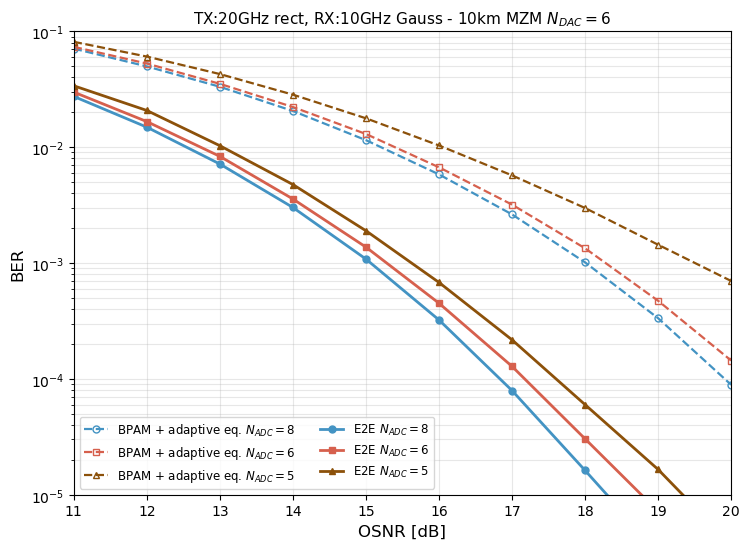

In [6]:
import shutil

STYLE = {8: ("o", "#4393c3"), 6: ("s", "#d6604d"), 5: ("^", "#8c510a")}
V3FIGS = r"C:\Users\celli\Documents\MATLAB\JLT_invited_OFC v3\figs"

def figure(axis, grid, xlabel, bkey, fname):
    fig, ax = plt.subplots(figsize=(7.6, 5.6))
    for nb in ADC_BITS:
        mk, c = STYLE[nb]
        pts = [(x, y) for x, y in zip(baseline[nb][bkey], baseline[nb]["ber"]) if y > 0]
        ax.semilogy([p[0] for p in pts], [p[1] for p in pts], "--" + mk, color=c, lw=1.6,
                    ms=5, mfc="none", label=f"BPAM + adaptive eq. $N_{{ADC}}={nb}$")
    for nb in ADC_BITS:
        mk, c = STYLE[nb]
        ax.semilogy(grid, np.maximum(results[axis][nb], 1e-7), "-" + mk, color=c, lw=2,
                    ms=5, label=f"E2E $N_{{ADC}}={nb}$")
    ax.set_xlim(min(grid), max(grid)); ax.set_ylim(1e-5, 1e-1); ax.set_xticks(grid)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("BER", fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8.5, loc="lower left", ncol=2)
    ax.set_title("TX:20GHz rect, RX:10GHz Gauss - 10km MZM $N_{DAC}=6$", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, fname + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(OUT, fname + ".png"), bbox_inches="tight", dpi=150)
    # no copy into v3/figs: this is an experiment, not a paper figure
    plt.show()

figure("osnr", OSNR_GRID, "OSNR [dB]", "osnr", "bpam_warmstart")

## 6b. Eye diagram of the photocurrent (what the receiver samples)

As in `pam4_analysis`: noiseless waveform of each trained transmitter, matched-filter output,
sampled at the phase that best separates the levels. With the discovered signaling the eye can
look closed — the decision lives in the RX context window, the eye documents the waveform.

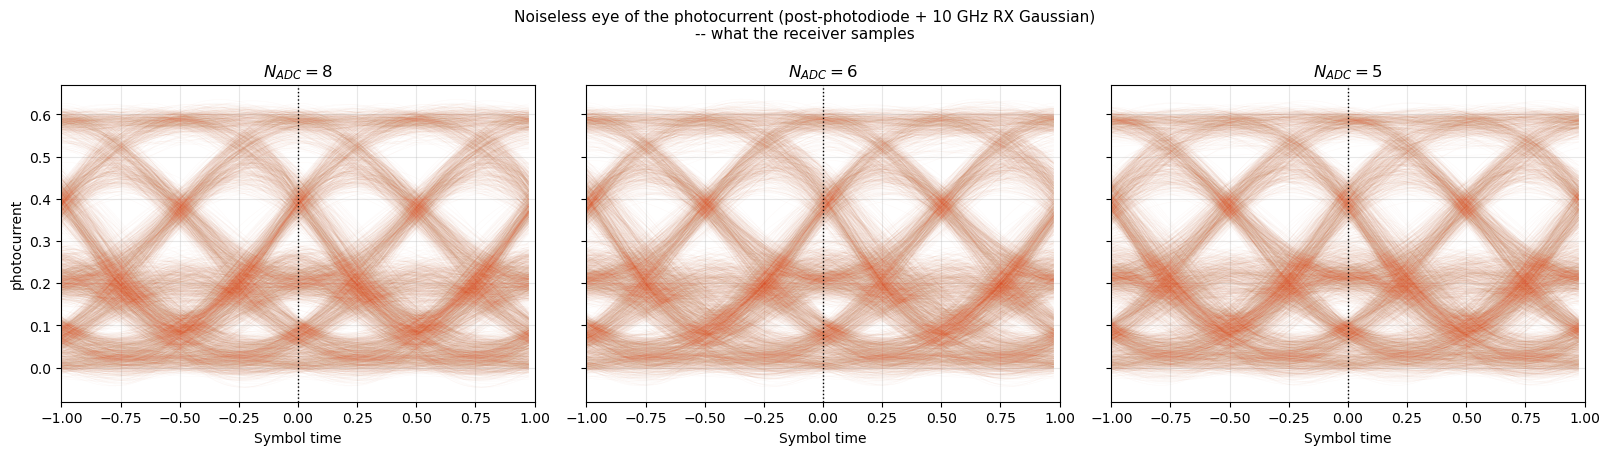

In [7]:
import torch.nn.functional as F
from scipy.signal import resample_poly
from train import random_bits
from transmitter import bits_to_symbols
from utils import decision_phase_by_separation

def draw_eye(ax, signal, samples_per_symbol, phase, title, fine_sps=40, skip=100, num_symbols=4000):
    fine = resample_poly(signal[:(skip + num_symbols + 8) * samples_per_symbol],
                         fine_sps, samples_per_symbol)
    offset = int(round(phase * fine_sps / samples_per_symbol))
    centers = (skip + np.arange(num_symbols)) * fine_sps + offset
    keep = (centers - fine_sps >= 0) & (centers + fine_sps < len(fine))
    centers = centers[keep]
    window = np.arange(-fine_sps, fine_sps)[:, None] + centers[None, :]
    ax.plot(np.arange(-fine_sps, fine_sps) / fine_sps, fine[window],
            color=(0.85, 0.33, 0.10, 0.03), linewidth=0.4)
    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Symbol time")
    ax.set_title(title)

fig, axes = plt.subplots(1, len(nets), figsize=(5.4 * len(nets), 4.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, (adc, (tx, ch, rx, cfg)) in zip(axes, nets.items()):
    sps = cfg.samples_per_symbol_sim
    torch.manual_seed(7)
    with torch.no_grad():
        bits = random_bits(cfg.bits_per_symbol, 6000, device)
        symbols = bits_to_symbols(bits, cfg.bits_per_symbol).cpu().numpy()
        p = ch(tx(bits), ase_ebn0_db=None)                    # noiseless photocurrent (post-photodiode)
        if rx.rx_gauss is not None:                           # 10 GHz RX Gaussian (the RX electrical filter)
            p = F.conv1d(p.view(1, 1, -1), rx.rx_gauss, padding=rx.rx_gauss.shape[-1] // 2).view(-1)
        photocurrent = p.cpu().numpy()
    phase, _ = decision_phase_by_separation(photocurrent, sps, symbols, skip=100)
    title = "ideal ADC" if adc is None else f"$N_{{ADC}}={adc}$"
    draw_eye(ax, photocurrent, sps, phase, title)
axes[0].set_ylabel("photocurrent")
fig.suptitle("Noiseless eye of the photocurrent (post-photodiode + 10 GHz RX Gaussian)\n"
             "-- what the receiver samples", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "bpam_warmstart_eyes.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Horizontal gain vs the reference, at equal ADC resolution

In [8]:
def crossing(x, y, target):
    x = np.asarray(x, float)
    ly = np.log10(np.maximum(np.asarray(y, float), 1e-12))
    lt = np.log10(target)
    for i in range(len(x) - 1):
        if (ly[i] - lt) * (ly[i + 1] - lt) <= 0:
            return x[i] + (x[i + 1] - x[i]) * (lt - ly[i]) / (ly[i + 1] - ly[i])
    return np.nan

for target in (1e-2, 1e-3):
    print(f"\nBER = {target:.0e}   (OSNR axis)")
    for nb in ADC_BITS:
        bx = [x for x, y in zip(baseline[nb]["osnr"], baseline[nb]["ber"]) if y > 0]
        by = [y for y in baseline[nb]["ber"] if y > 0]
        gb = crossing(bx, by, target)
        ge = crossing(OSNR_GRID, results["osnr"][nb], target)
        print(f"  N_ADC={nb}:  baseline @ {gb:5.2f} dB   E2E @ {ge:5.2f} dB"
              f"   ->  gain {gb - ge:+.2f} dB")


BER = 1e-02   (OSNR axis)
  N_ADC=8:  baseline @ 15.21 dB   E2E @ 12.54 dB   ->  gain +2.66 dB
  N_ADC=6:  baseline @ 15.40 dB   E2E @ 12.74 dB   ->  gain +2.66 dB
  N_ADC=5:  baseline @ 16.06 dB   E2E @ 13.04 dB   ->  gain +3.02 dB

BER = 1e-03   (OSNR axis)
  N_ADC=8:  baseline @ 18.01 dB   E2E @ 15.07 dB   ->  gain +2.95 dB
  N_ADC=6:  baseline @ 18.28 dB   E2E @ 15.28 dB   ->  gain +3.00 dB
  N_ADC=5:  baseline @ 19.51 dB   E2E @ 15.62 dB   ->  gain +3.88 dB
